In [6]:
# 📊 Dataset
# Medical Cost Personal Insurance Dataset
# Kaggle Link: https://www.kaggle.com/datasets/mirichoi0218/insurance


import kagglehub
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [2]:
# Task 1: Data Understanding

import pandas as pd
import numpy as np
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Task 2: Data Preprocessing

from sklearn.model_selection import train_test_split
print("Missing values in each column:\n", df.isnull().sum())
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Missing values in each column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Training data shape: (1070, 8)
Testing data shape: (268, 8)


In [4]:
# Task 3: Model Development

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

            Feature   Coefficient
4        smoker_yes  23651.128856
2          children    425.278784
1               bmi    337.092552
0               age    256.975706
3          sex_male    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
R-squared (R2) Score: 0.7836


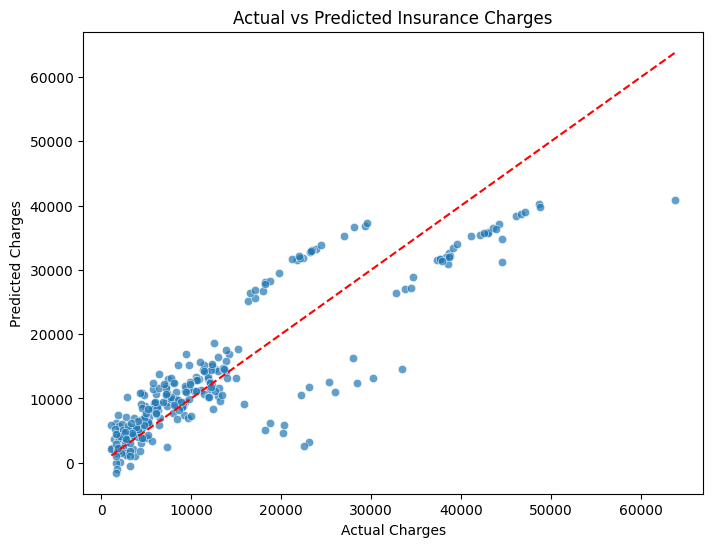

In [5]:
# Task 4: Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Insurance Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.show()

Task 5: Conclusion

The multiple linear regression model successfully identifies the primary drivers of medical insurance costs the most crucial finding is that a persons smoking status dictates the highest increase in medical charges overwhelming all other variables demographic details like region and gender show minimal impact compared to core health metrics both age and body mass index steadily drive up expected costs as they increase one major limitation of applying linear regression to this problem is its strict assumption of independent linear relationships the model simply adds the independent effects of features together meaning it fails to recognize complex overlapping interactions higher body mass index causes a massive surge in medical costs almost exclusively for people who smoke but a standard linear model cannot naturally detect this combined effect without manually creating new interaction features.